Import libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

Set paths

In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_news.csv"

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data path:", CLEANED_DATA_PATH)

Project root: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector
Cleaned data path: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\data\processed\cleaned_news.csv


Load cleaned dataset

In [3]:
data = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", data.shape)
print(data.columns)

display(data.head())

Dataset shape: (39098, 3)
Index(['content', 'clean_text', 'label'], dtype='str')


,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Duri...,pope francis called donald trump christmas spe...,0


Prepare features and labels

In [4]:
data["clean_text"] = data["clean_text"].fillna("").astype(str)

X = data["clean_text"]
y = data["label"].astype(int)

print("Total records:", len(X))
print("Class distribution:")
print(y.value_counts())

Total records: 39098
Class distribution:
label
1    21196
0    17902
Name: count, dtype: int64


Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 31278
Testing size: 7820


TF-IDF feature extraction

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (31278, 5000)
X_test_tfidf shape: (7820, 5000)


Train Logistic Regression model

In [7]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


Predictions

In [14]:
def predict_news_logistic_regression(text):
    # Apply same preprocessing used during training
    cleaned_text = clean_text(text)

    # Convert cleaned text to TF-IDF features
    text_tfidf = tfidf_vectorizer.transform([cleaned_text])

    # Predict class
    prediction = lr_model.predict(text_tfidf)[0]

    # Predict probability
    probability = lr_model.predict_proba(text_tfidf)[0]

    result = "Real News" if prediction == 1 else "Fake News"
    confidence = probability[prediction]

    return result, confidence

Evaluation metrics

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Logistic Regression Evaluation Results")
print("--------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake News", "Real News"]))

Logistic Regression Evaluation Results
--------------------------------------
Accuracy : 0.9859335038363172
Precision: 0.9831500117013807
Recall   : 0.99103562160887
F1-score : 0.9870770676691729
ROC-AUC  : 0.9989352338516451

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.98      3581
   Real News       0.98      0.99      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



Confusion matrix

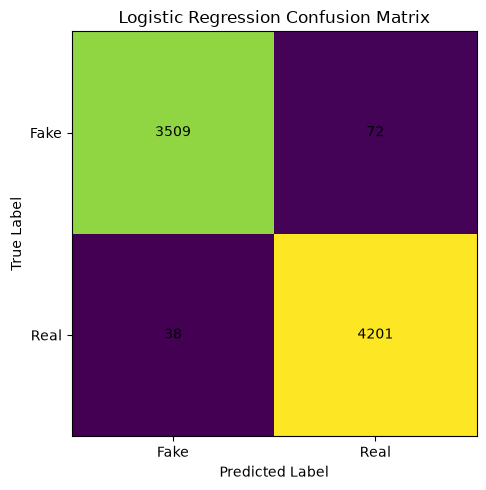

[[3509   72]
 [  38 4201]]


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lr_confusion_matrix.png")
plt.show()

print(cm)

Save metrics

In [11]:
metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "max_features": 5000,
    "ngram_range": "1,2",
    "C": 1.0
}

metrics_df = pd.DataFrame([metrics])

metrics_path = METRICS_DIR / "logistic_regression_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)

print("Metrics saved to:", metrics_path)

,model,accuracy,precision,recall,f1_score,roc_auc,max_features,ngram_range,C
0,Logistic Regression,0.985934,0.98315,0.991036,0.987077,0.998935,5000,"1,2",1.0


Metrics saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\reports\metrics\logistic_regression_metrics.csv


Save model and vectorizer

In [12]:
model_path = MODELS_DIR / "logistic_regression_model.joblib"
vectorizer_path = MODELS_DIR / "tfidf_vectorizer.joblib"

joblib.dump(lr_model, model_path)
joblib.dump(tfidf_vectorizer, vectorizer_path)

print("Model saved to:", model_path)
print("Vectorizer saved to:", vectorizer_path)

Model saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\models\logistic_regression_model.joblib
Vectorizer saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\models\tfidf_vectorizer.joblib


Test with custom news text

In [19]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)


def predict_news_logistic_regression(news):
    cleaned_news = clean_text(news)

    news_tfidf = tfidf_vectorizer.transform([cleaned_news])

    prediction = lr_model.predict(news_tfidf)[0]
    probabilities = lr_model.predict_proba(news_tfidf)[0]

    confidence = probabilities[prediction]

    if prediction == 0:
        result = "Fake News"
    else:
        result = "Real News"

    return result, confidence


sample_news = """
The government announced a new economic reform package during an official press conference.
According to the finance ministry, the reform plan aims to improve tax collection,
reduce public spending, and support small businesses through new loan schemes.
Officials stated that the policy will be implemented in several phases over the next year.
"""

result, confidence = predict_news_logistic_regression(sample_news)

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: Real News
Confidence: 61.21 %
